# **BANK CUSTOMER CHURN ANALYSIS**
Exploratory Data Analysis — Dataset: Bank Customer Records  |  Tools: Python, Pandas, Matplotlib

objective: Mengidentifikasi pola dan faktor-faktor utama yang mendorong nasabah untuk meninggalkan layanan bank (*customer churn*).

---

## **Latar Belakang:**

Customer churn merupakan salah satu tantangan terbesar dalam industri perbankan. Kehilangan nasabah tidak hanya berdampak pada pendapatan, tetapi juga meningkatkan biaya akuisisi pelanggan baru yang jauh lebih mahal dibandingkan mempertahankan nasabah yang ada. Analisis ini bertujuan untuk memahami **siapa nasabah yang paling berisiko churn** dan **faktor apa yang paling berpengaruh**, sehingga bank dapat mengambil tindakan pencegahan yang tepat sasaran.









# 1. Import Library & Load Data



In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['axes.titlesize'] = 12

path = "/content/drive/MyDrive/Colab Notebooks/bank-churn-analysis/data/data.csv"
df = pd.read_csv(path)

print("Dataset berhasil dimuat")
df.head()

Dataset berhasil dimuat


,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


# 2. Data Understanding & Cleaning

In [ ]:
print("=" * 45)
print("       INFORMASI DATASET")
print("=" * 45)
print(df.info())

print("\n📋 Missing Values per Kolom:")
print(df.isnull().sum())

df = df.drop(columns=["customer_id"], errors="ignore")
print(f"\nJumlah baris duplikat: {df.duplicated().sum()}")
df = df.drop_duplicates()
print("Data sudah bersih, siap dianalisis.")

       INFORMASI DATASET
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customer_id       10000 non-null  int64  
 1   credit_score      10000 non-null  int64  
 2   country           10000 non-null  object 
 3   gender            10000 non-null  object 
 4   age               10000 non-null  int64  
 5   tenure            10000 non-null  int64  
 6   balance           10000 non-null  float64
 7   products_number   10000 non-null  int64  
 8   credit_card       10000 non-null  int64  
 9   active_member     10000 non-null  int64  
 10  estimated_salary  10000 non-null  float64
 11  churn             10000 non-null  int64  
dtypes: float64(2), int64(8), object(2)
memory usage: 937.6+ KB
None

📋 Missing Values per Kolom:
customer_id         0
credit_score        0
country             0
gender              0
age                 0
t

# 3. Overview: Churn Rate Keseluruhan

> **Metrik pertama yang perlu dipahami** adalah seberapa besar proporsi nasabah yang churn secara keseluruhan.

In [ ]:
total_customers = len(df)
churn_customers = df["churn"].sum()
churn_rate = df["churn"].mean() * 100

print("=" * 40)
print(f"  Total Nasabah     : {total_customers:,}")
print(f"  Nasabah Churn     : {churn_customers:,}")
print(f"  Churn Rate        : {churn_rate:.2f}%")
print("=" * 40)

  Total Nasabah     : 10,000
  Nasabah Churn     : 2,037
  Churn Rate        : 20.37%


Insight: Churn Rate Keseluruhan

> **Churn rate berada di angka ~20%**, artinya 1 dari 5 nasabah meninggalkan layanan bank. Angka ini tergolong **signifikan** dan mengindikasikan perlunya strategi retensi yang lebih proaktif. Untuk konteks industri perbankan, churn rate yang sehat umumnya di bawah 10%.

# 4. Churn Rate by Country

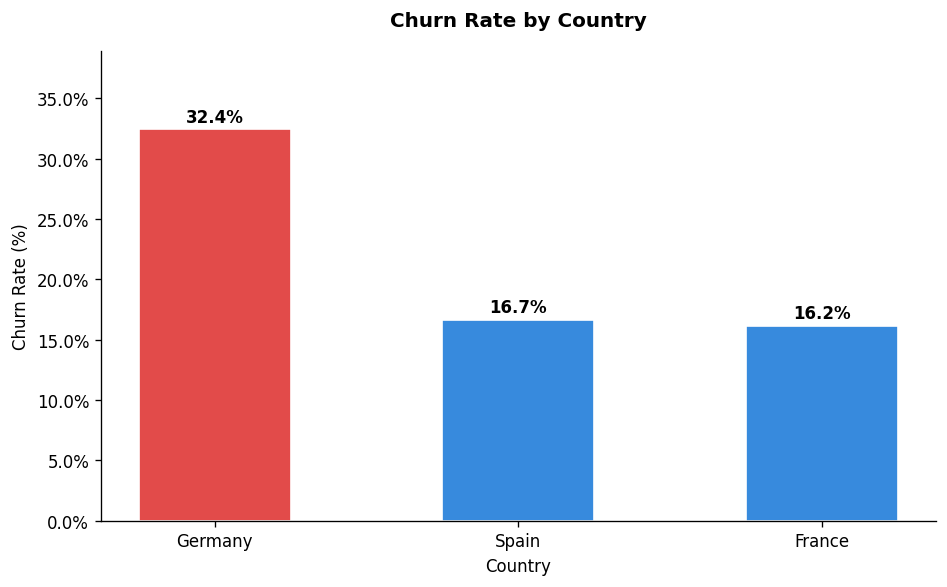

In [ ]:
country_churn = df.groupby("country")["churn"].mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(country_churn.index, country_churn.values * 100,
              color=['#E24B4A' if v == country_churn.max() else '#378ADD' for v in country_churn.values],
              width=0.5, edgecolor='white')

for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.3,
            f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_title("Churn Rate by Country", pad=15)
ax.set_ylabel("Churn Rate (%)")
ax.set_xlabel("Country")
ax.set_ylim(0, country_churn.max() * 100 * 1.2)
plt.tight_layout()
plt.show()


Insight: Churn Berdasarkan Negara

> Terdapat **variasi churn rate yang signifikan antar negara**. Negara dengan churn rate tertinggi kemungkinan menghadapi tantangan kompetitif yang lebih besar dari bank lain, atau kualitas layanan di wilayah tersebut belum memenuhi ekspektasi nasabah lokal. **Strategi retensi perlu disesuaikan per wilayah**, bukan pendekatan satu ukuran untuk semua.

# 5. Churn Distribution by Gender

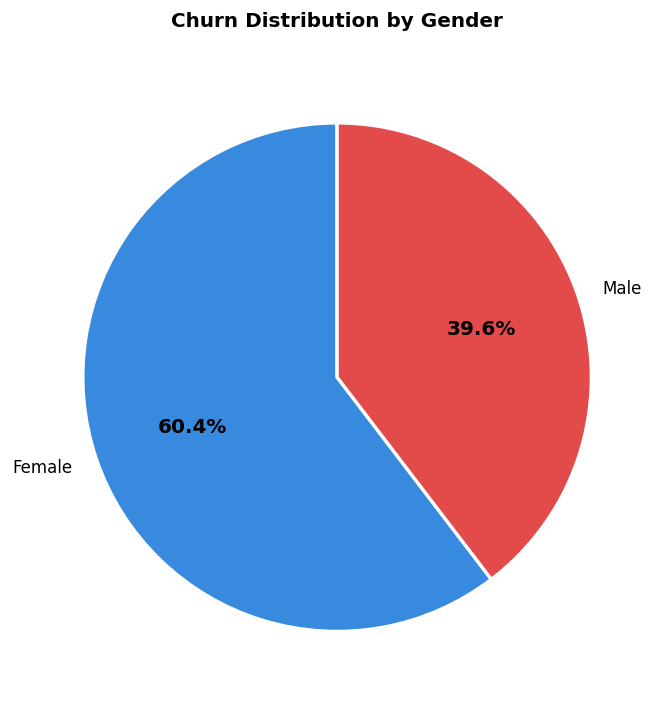

In [ ]:
gender = df.groupby("gender")["churn"].mean()

fig, ax = plt.subplots(figsize=(6, 6))
colors = ['#378ADD', '#E24B4A']
wedges, texts, autotexts = ax.pie(
    gender.values, labels=gender.index, autopct='%1.1f%%',
    colors=colors, startangle=90,
    wedgeprops=dict(edgecolor='white', linewidth=2)
)
for autotext in autotexts:
    autotext.set_fontweight('bold')
    autotext.set_fontsize(12)

ax.set_title("Churn Distribution by Gender", pad=20)
plt.tight_layout()
plt.show()

 Insight: Churn Berdasarkan Gender

> **Nasabah perempuan memiliki churn rate yang lebih tinggi** dibandingkan laki-laki. Temuan ini mengindikasikan bahwa produk atau layanan bank mungkin **kurang relevan atau memuaskan bagi segmen perempuan**. Diperlukan analisis lebih lanjut terkait preferensi dan kebutuhan spesifik nasabah perempuan untuk merancang penawaran yang lebih tepat sasaran.

# 6. Churn Rate by Age

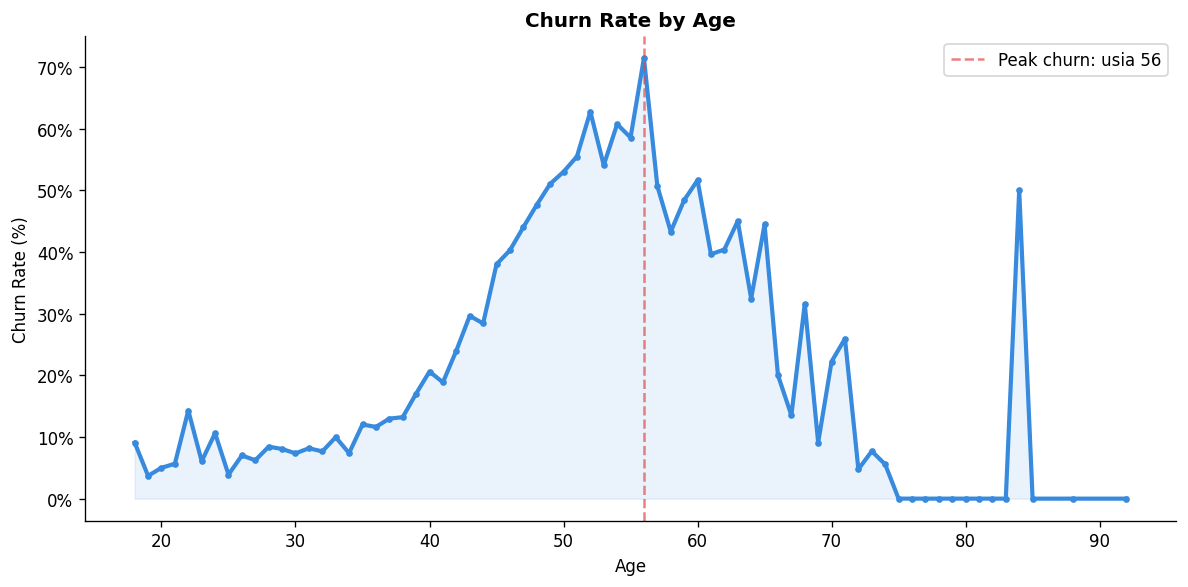

In [ ]:
age_churn = df.groupby("age")["churn"].mean()

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(age_churn.index, age_churn.values * 100,
        color='#378ADD', linewidth=2.5, marker='o', markersize=3)
ax.fill_between(age_churn.index, age_churn.values * 100, alpha=0.1, color='#378ADD')

peak_age = age_churn.idxmax()
ax.axvline(x=peak_age, color='#E24B4A', linestyle='--', alpha=0.7, label=f'Peak churn: usia {peak_age}')
ax.legend()

ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_title("Churn Rate by Age")
ax.set_ylabel("Churn Rate (%)")
ax.set_xlabel("Age")
plt.tight_layout()
plt.show()

Insight: Churn Berdasarkan Usia

> Churn rate **meningkat tajam pada kelompok usia 40–60 tahun** dan mencapai puncaknya di sekitar usia tersebut. Kelompok usia ini biasanya memiliki kebutuhan finansial yang lebih kompleks (perencanaan pensiun, investasi, asuransi) dan ekspektasi layanan yang lebih tinggi. Mereka juga lebih berani beralih ke bank lain jika layanan yang diterima tidak memuaskan. **Segmen usia 40–60 tahun harus menjadi prioritas utama program retensi.**

# 7. Distribution of Customer Balance

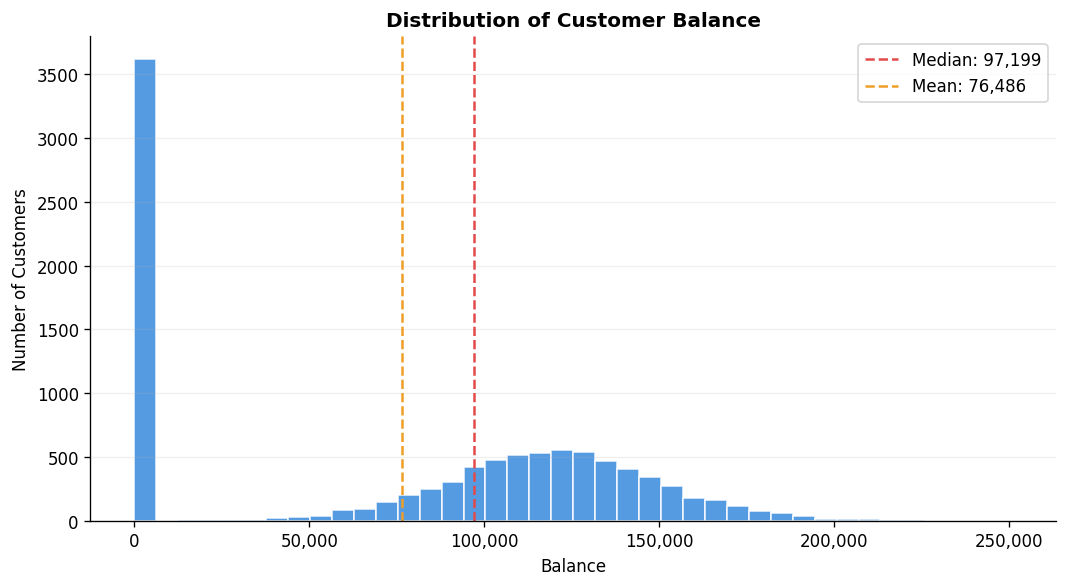

In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(df["balance"], bins=40, color='#378ADD', edgecolor='white', alpha=0.85)
ax.axvline(df['balance'].median(), color='#E24B4A', linestyle='--', linewidth=1.5,
           label=f'Median: {df["balance"].median():,.0f}')
ax.axvline(df['balance'].mean(), color='#EF9F27', linestyle='--', linewidth=1.5,
           label=f'Mean: {df["balance"].mean():,.0f}')
ax.legend()
ax.set_title("Distribution of Customer Balance")
ax.set_xlabel("Balance")
ax.set_ylabel("Number of Customers")
ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.grid(axis='y', alpha=0.2)
plt.tight_layout()
plt.show()

Insight: Distribusi Saldo Nasabah

> Distribusi saldo menunjukkan **pola bimodal**: terdapat kelompok besar nasabah dengan saldo mendekati nol, dan kelompok lain dengan saldo menengah-tinggi. Nasabah dengan **saldo nol kemungkinan besar adalah nasabah dormant (tidak aktif)** yang berpotensi tinggi untuk churn. Sementara itu, potensi kerugian finansial terbesar berasal dari nasabah bersaldo tinggi yang memilih untuk keluar. Kedua segmen ini memerlukan pendekatan retensi yang berbeda.

# 8. Churn Rate by Number of Products

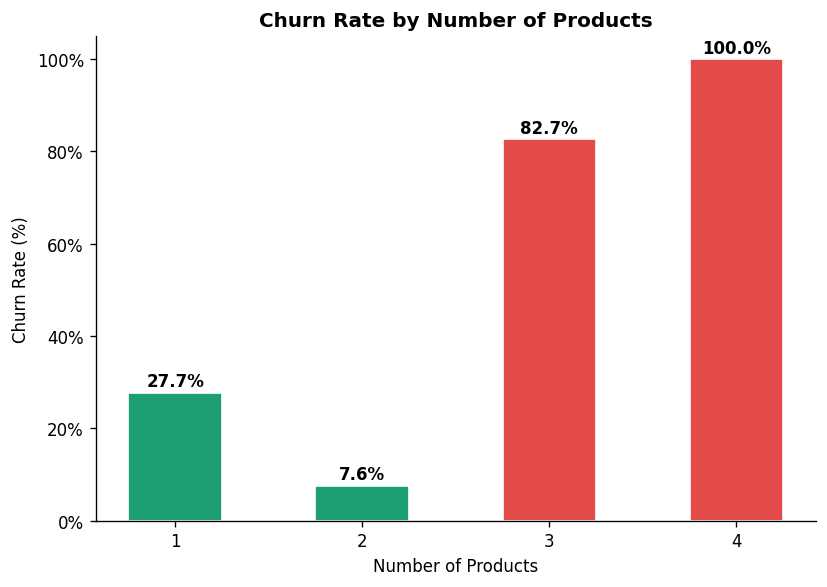

In [ ]:
product_churn = df.groupby("products_number")["churn"].mean().sort_index()

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(product_churn.index.astype(str), product_churn.values * 100,
              color=['#1D9E75' if v < 0.3 else '#E24B4A' for v in product_churn.values],
              width=0.5, edgecolor='white')

for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.5,
            f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_title("Churn Rate by Number of Products")
ax.set_ylabel("Churn Rate (%)")
ax.set_xlabel("Number of Products")
plt.tight_layout()
plt.show()

 Insight: Churn Berdasarkan Jumlah Produk

> Temuan ini bersifat **kontra-intuitif namun krusial**: nasabah yang menggunakan **3–4 produk justru memiliki churn rate tertinggi**, sementara nasabah dengan 1–2 produk relatif lebih loyal. Hal ini kemungkinan menunjukkan bahwa nasabah yang terlalu banyak berinteraksi dengan produk bank mengalami **friction atau kompleksitas yang tidak nyaman**, atau mereka adalah nasabah yang paling aktif mencari dan membandingkan pilihan terbaik di pasar. Perlu dilakukan review pada customer journey nasabah multi-produk.

# 9. Churn Rate by Credit Card Ownership

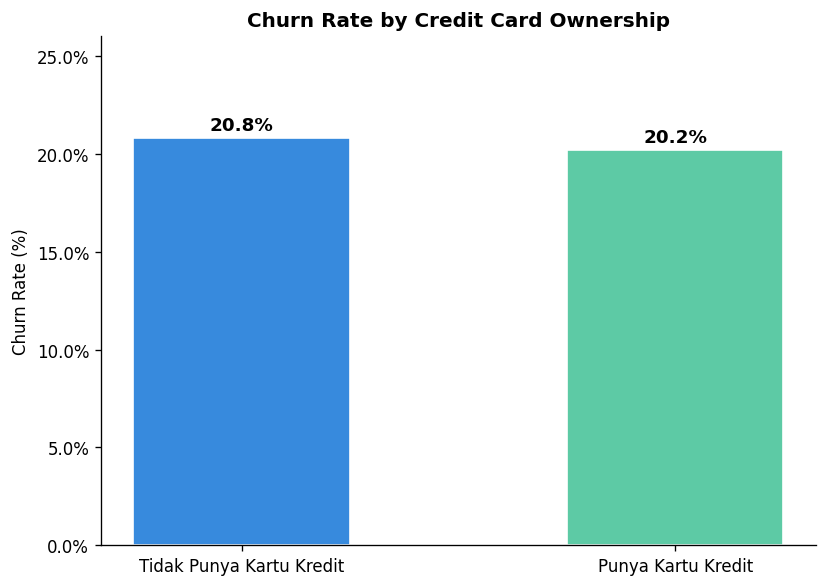

In [ ]:
creditcard_churn = df.groupby("credit_card")["churn"].mean().sort_values(ascending=False)
labels = {0: 'Tidak Punya Kartu Kredit', 1: 'Punya Kartu Kredit'}

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar([labels.get(i, str(i)) for i in creditcard_churn.index],
              creditcard_churn.values * 100,
              color=['#378ADD', '#5DCAA5'], width=0.5, edgecolor='white')

for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.2,
            f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_title("Churn Rate by Credit Card Ownership")
ax.set_ylabel("Churn Rate (%)")
ax.set_ylim(0, creditcard_churn.max() * 100 * 1.25)
plt.tight_layout()
plt.show()

Insight: Churn Berdasarkan Kepemilikan Kartu Kredit

> Kepemilikan kartu kredit **tidak memberikan perbedaan yang signifikan** terhadap churn rate. Artinya, produk kartu kredit saja tidak cukup untuk menciptakan loyalitas nasabah. Ini menyiratkan bahwa **engagement dan kualitas hubungan dengan nasabah jauh lebih penting** dibandingkan sekadar jumlah produk yang dimiliki.

# 10. Churn by Active Member Status

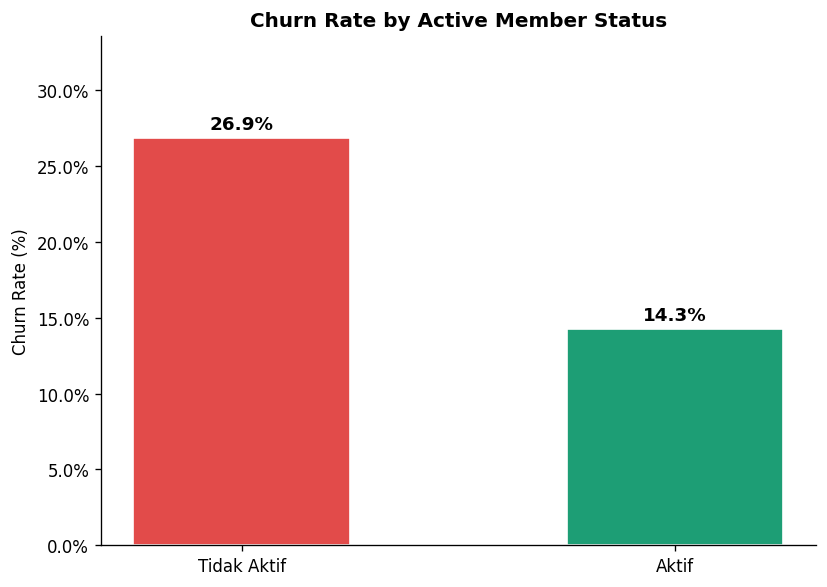

In [ ]:
active = df.groupby("active_member")["churn"].mean()
labels_active = {0: 'Tidak Aktif', 1: 'Aktif'}

fig, ax = plt.subplots(figsize=(7, 5))
colors_bar = ['#E24B4A', '#1D9E75']
bars = ax.bar([labels_active.get(i, str(i)) for i in active.index],
              active.values * 100,
              color=colors_bar, width=0.5, edgecolor='white')

for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.3,
            f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_title("Churn Rate by Active Member Status")
ax.set_ylabel("Churn Rate (%)")
ax.set_ylim(0, active.max() * 100 * 1.25)
plt.tight_layout()
plt.show()

Insight: Churn Berdasarkan Status Keaktifan

> **Nasabah yang tidak aktif memiliki churn rate jauh lebih tinggi** dibandingkan yang aktif. Tingkat aktivitas merupakan **salah satu prediktor terkuat untuk churn**. Ini memberi peluang bagi bank untuk membangun sistem peringatan dini: ketika aktivitas nasabah mulai menurun, segera kirimkan penawaran atau sentuhan personal untuk re-engage mereka sebelum memutuskan untuk keluar.

# 11. Balance Distribution: Churn vs Non-Churn

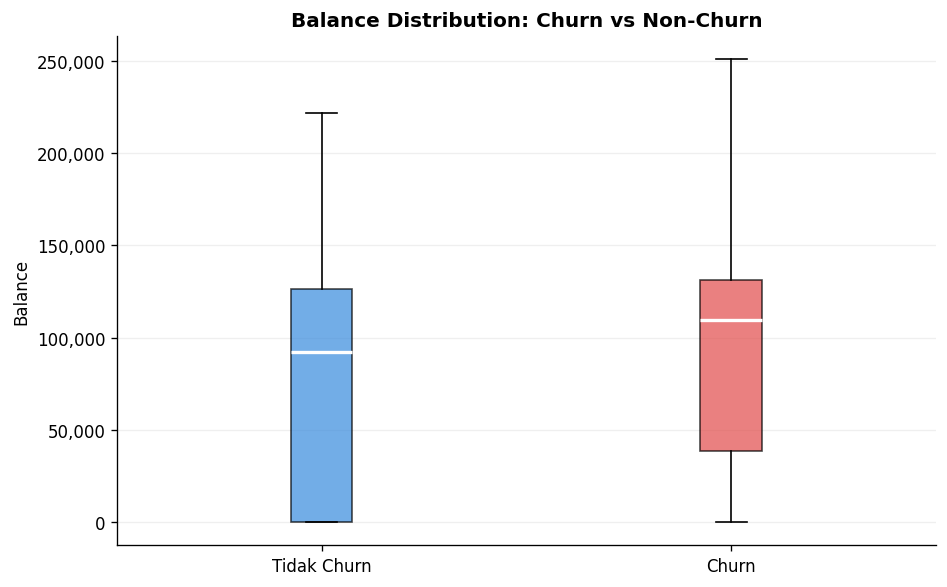

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))
churn_labels = {0: 'Tidak Churn', 1: 'Churn'}
colors_box = ['#378ADD', '#E24B4A']

groups = [df[df['churn'] == k]['balance'].values for k in sorted(df['churn'].unique())]
bp = ax.boxplot(groups, patch_artist=True,
                medianprops=dict(color='white', linewidth=2))

for patch, color in zip(bp['boxes'], colors_box):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.set_xticklabels([churn_labels[k] for k in sorted(df['churn'].unique())])
ax.set_title("Balance Distribution: Churn vs Non-Churn")
ax.set_ylabel("Balance")
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.grid(axis='y', alpha=0.2)
plt.tight_layout()
plt.show()

Insight: Saldo vs Churn

> Nasabah yang churn cenderung memiliki **median saldo yang lebih tinggi** dibandingkan yang tidak churn. Ini merupakan temuan yang penting dari perspektif bisnis, nasabah yang pergi bukan hanya yang memiliki saldo kecil, melainkan juga nasabah berharga dengan saldo yang signifikan. **Potensi kerugian finansial dari churn jauh lebih besar dari yang terlihat jika hanya melihat persentase nasabah.**

In [ ]:
print('=' * 50)
print('        CHURN SUMMARY STATISTICS')
print('=' * 50)

print('\n By Country:')
print(df.groupby('country')['churn'].agg(['mean','sum'])
       .rename(columns={'mean':'Churn Rate','sum':'Total Churn'})
       .assign(**{'Churn Rate': lambda x: (x['Churn Rate']*100).round(1).astype(str)+'%'})
       .to_string())

print('\n\n By Gender:')
print(df.groupby('gender')['churn'].agg(['mean','sum'])
       .rename(columns={'mean':'Churn Rate','sum':'Total Churn'})
       .assign(**{'Churn Rate': lambda x: (x['Churn Rate']*100).round(1).astype(str)+'%'})
       .to_string())

print('\n\n By Products Number:')
print(df.groupby('products_number')['churn'].agg(['mean','sum'])
       .rename(columns={'mean':'Churn Rate','sum':'Total Churn'})
       .assign(**{'Churn Rate': lambda x: (x['Churn Rate']*100).round(1).astype(str)+'%'})
       .to_string())

print('\n\n By Active Member:')
active_labels = {0: 'Tidak Aktif', 1: 'Aktif'}
tmp = df.groupby('active_member')['churn'].agg(['mean','sum'])
tmp.index = tmp.index.map(active_labels)
print(tmp.rename(columns={'mean':'Churn Rate','sum':'Total Churn'})
         .assign(**{'Churn Rate': lambda x: (x['Churn Rate']*100).round(1).astype(str)+'%'})
         .to_string())

        CHURN SUMMARY STATISTICS

 By Country:
        Churn Rate  Total Churn
country                        
France       16.2%          810
Germany      32.4%          814
Spain        16.7%          413


 By Gender:
       Churn Rate  Total Churn
gender                        
Female      25.1%         1139
Male        16.5%          898


 By Products Number:
                Churn Rate  Total Churn
products_number                        
1                    27.7%         1409
2                     7.6%          348
3                    82.7%          220
4                   100.0%           60


 By Active Member:
              Churn Rate  Total Churn
active_member                        
Tidak Aktif        26.9%         1302
Aktif              14.3%          735


---

## Ringkasan Eksekutif

### Temuan Utama

| # | Temuan | Dampak |
|---|--------|--------|
| 1 | Churn rate ~20% — 1 dari 5 nasabah meninggalkan bank | Tinggi |
| 2 | Nasabah perempuan lebih rentan churn dibanding laki-laki | Sedang |
| 3 | Segmen usia 40–60 tahun adalah kelompok paling berisiko | Tinggi |
| 4 | Nasabah dengan 3–4 produk justru memiliki churn tertinggi | Tinggi |
| 5 | Nasabah tidak aktif memiliki churn rate jauh lebih besar | Tinggi |
| 6 | Nasabah yang churn cenderung memiliki saldo lebih tinggi | Tinggi |
| 7 | Kepemilikan kartu kredit tidak berpengaruh signifikan | Rendah |
| 8 | Churn bervariasi secara geografis antar negara | Sedang |

---

## Rekomendasi Bisnis

Berdasarkan temuan di atas, berikut adalah empat rekomendasi strategis yang dapat diambil:

**1. Program Retensi Berbasis Usia**  
Rancang program loyalitas khusus untuk segmen nasabah usia 40–60 tahun, misalnya layanan wealth management, konsultasi finansial personal, atau benefit eksklusif yang relevan dengan kebutuhan hidup mereka.

**2. Sistem Early Warning untuk Nasabah Tidak Aktif**  
Bangun sistem otomatis yang mendeteksi penurunan aktivitas nasabah, lalu secara proaktif mengirimkan re-engagement campaign (promo, konten edukasi finansial, atau penawaran produk baru) sebelum nasabah memutuskan untuk pergi.

**3. Tinjauan Ulang Customer Journey Multi-Produk**  
Lakukan audit pada pengalaman nasabah yang menggunakan banyak produk. Pastikan kompleksitas pengelolaan beberapa produk tidak menciptakan rasa frustrasi atau ketidaknyamanan yang mendorong churn.

**4. Pendekatan Tersegmentasi per Gender dan Wilayah**  
Kembangkan survei kepuasan khusus untuk nasabah perempuan dan lakukan analisis perbedaan churn antar negara untuk mengidentifikasi gap layanan yang perlu diperbaiki di masing-masing pasar.

---

*Analisis ini merupakan bagian dari eksplorasi data awal (EDA). Langkah selanjutnya yang disarankan adalah membangun **model prediktif** (Logistic Regression / Random Forest) untuk memprediksi nasabah yang berisiko churn secara lebih akurat.*